In [336]:
import numpy as np
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm

num_loci = 500
num_inds = 10000
p_init = 0.2
beta = 0.0075
num_gens = 500
sel_type = "stabilizing"
omega = 0.1
dz = 0.005
ld_gens = 11

sum_ld = np.zeros(ld_gens)

h2 = 1

vg_init = 2*np.sum(betas_array **2 * p_init * (1-p_init), axis=0)
ve = (vg_init - h2*vg_init)/h2

def delta_p_base(p, beta_f, omega_f):
    return p * (1 - p) * (p - 0.5) * beta_f**2 / omega_f**2

def delta_p_var(p, beta_f, omega_f, vg):
    return p * (1 - p) * (p - 0.5) * beta_f**2 / (omega_f**2 + vg)

def delta_p_semibulmer(p, beta_f, omega_f, vg):
    X = (omega_f**2 + 0) / vg
    d_over_vg = (3 + X - np.sqrt(1 + 6 * X + X**2)) / 4
    return p * (1 - p) * (p - 0.5) * beta_f**2 / (omega_f**2 + vg * (1-d_over_vg))

def delta_p_fullbulmer(p, beta_f, omega_f, vg):
    X = (omega_f**2 + 0) / vg
    d_over_vg = (3 + X - np.sqrt(1 + 6 * X + X**2)) / 4
    return p * (1 - p) * (p - 0.5) * beta_f**2 * (1 - d_over_vg)**2 / (omega_f**2 + vg * (1-d_over_vg))

def delta_p_dir(p, beta_f, dz_f, omega_f):
    return p * (1-p) * beta_f * dz_f / (omega_f**2)

In [337]:
rng = np.random.default_rng(5)

betas_array = np.zeros(num_loci) + beta
betas_array[num_loci//2:] *= -1
p_t = np.zeros((num_loci, num_gens+1))
p_t[:, 0] = p_init
init_states = np.zeros((num_loci, num_inds * 2), dtype=bool)
for l_i in tqdm(np.arange(num_loci)):
    init_states[l_i, :int(p_t[l_i, 0] * 2 * num_inds)] = 1
    rng.shuffle(init_states[l_i])
g_t = init_states

if sel_type == "stabilizing":
    haplo_phenos = np.sum(g_t * betas_array[:, np.newaxis], axis=0)
    ind_phenos = haplo_phenos[::2] + haplo_phenos[1::2]
    z0 = np.mean(ind_phenos)

l_range = np.arange(num_loci)
for gen_i in tqdm(np.arange(num_gens)):
    z_haplo = np.sum(g_t * betas_array[:, np.newaxis], axis=0)
    z_ind = z_haplo[::2] + z_haplo[1::2]
    if ve > 0:
        z_ind += rng.normal(0, scale=np.sqrt(ve), size=z_ind.shape[0])
    #compute w(z)
    if sel_type == "stabilizing":
        w_t = np.exp(-(z_ind - z0)**2/(2*omega**2))
    elif sel_type == "directional":
        w_t = np.exp(-(z_ind * dz)/(omega**2))
    # plt.hist(w_t, bins="auto")
    # plt.show()
    #reproduce

    if gen_i < ld_gens:
        calldata_signcorrected = np.copy(g_t)
        calldata_signcorrected[betas_array < 0, :] = 1 - calldata_signcorrected[betas_array < 0, :]
        Ds = np.array([0])
        pas = np.sum(calldata_signcorrected, axis=-1)/(calldata_signcorrected.shape[1])
        for i in np.arange(calldata_signcorrected.shape[0]):
            pab = np.sum(calldata_signcorrected[i, :] * calldata_signcorrected, axis=-1)/(calldata_signcorrected.shape[1])
            papb = pas[i]*pas
            Ds = np.concatenate((Ds, (pab-papb)[i+1:]))
        sum_ld[gen_i] = np.sum(Ds)
 
    g_tp1 = np.zeros_like(g_t)
    big_haplo_rng = rng.uniform(size=(num_loci, num_inds * 2))
    parents = rng.choice(np.arange(num_inds), size=(num_inds * 2), p = w_t/np.sum(w_t))
    num_children = np.zeros_like(w_t)
    # for i in np.arange(num_inds):
    #     num_children[i] = (parents==i).sum()
    # for k in np.arange(np.max(num_children)):
    #     print(f"{k} children: {np.mean(w_t[num_children==k])}")
    for ind_i in np.arange(num_inds*2):
        g_tp1[:, ind_i] = np.where(big_haplo_rng[:, ind_i] < 0.5, g_t[:, parents[ind_i]*2], g_t[:, parents[ind_i]*2+1])
    p_t[:, gen_i+1] = g_tp1.sum(axis=-1)/(2*num_inds)
    g_t = g_tp1

  0%|          | 0/500 [00:00<?, ?it/s]

  0%|          | 0/500 [00:00<?, ?it/s]

In [318]:
if sel_type == "stabilizing":
    ps_base = np.zeros(num_gens+1)
    ps_base[0] = p_init
    ps_var = np.zeros_like(ps_base)
    ps_var[0] = p_init
    ps_semibulmer = np.zeros_like(ps_base)
    ps_semibulmer[0] = p_init
    ps_fullbulmer = np.zeros_like(ps_base)
    ps_fullbulmer[0] = p_init
    
    for gen_i in np.arange(num_gens):
        ps_base[gen_i+1] = ps_base[gen_i] + delta_p_base(ps_base[gen_i], beta, omega)
        ps_var[gen_i+1] = ps_var[gen_i] + delta_p_var(ps_var[gen_i], beta, omega, vg_init)
        ps_semibulmer[gen_i+1] = ps_semibulmer[gen_i] + delta_p_semibulmer(ps_semibulmer[gen_i], beta, omega, vg_init)
        ps_fullbulmer[gen_i+1] = ps_fullbulmer[gen_i] + delta_p_fullbulmer(ps_fullbulmer[gen_i], beta, omega, vg_init)
else:
    ps_dir = np.zeros(num_gens+1)
    ps_dir[0] = p_init

    for gen_i in np.arange(num_gens):
        ps_dir[gen_i+1] = ps_dir[gen_i] + delta_p_dir(ps_dir[gen_i], beta, dz, omega)

In [326]:
slim_data = np.loadtxt("../../../polyoutput/slim_testing/GWASFULLL/GWASFULL_w0.1_s1_slim.txt", skiprows=1).T
slim_data = np.loadtxt("../../../polyoutput/slim_testing/GWASDIR/GWASDIR_w0.1_s0_slim.txt", skiprows=1).T

In [327]:
#%load_ext line_profiler

In [328]:
#%lprun -f loop_func loop_func(p_t, g_t, betas_array, z0, sel_type, omega, rng)

In [329]:
plt.plot(2*np.sum(betas_array[:, np.newaxis] **2 * p_t * (1-p_t), axis=0))
plt.plot(2*np.sum(betas_array[:, np.newaxis]**2 * slim_data[3:, :] * (1-slim_data[3:, :]), axis=0))
plt.show()

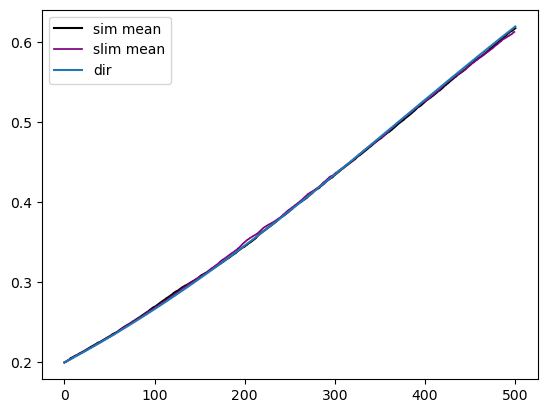

In [330]:
#plt.plot(p_t.T)
plt.plot(np.mean(p_t[betas_array < 0], axis=0), color="k", lw=1.5, label="sim mean")
plt.plot(np.mean(slim_data[3:250, :], axis=0), color="purple", lw=1.25, label="slim mean")
plt.plot(ps_dir, label="dir")
# plt.plot(ps_base, label=r"$\frac{1}{\omega^2}$")
# plt.plot(ps_var, label=r"$\frac{1}{\omega^2 + V_g}$")
# plt.plot(ps_semibulmer, label = "semi-bulmer")
# plt.plot(ps_fullbulmer, label = "full bulmer")
plt.legend()
plt.show()

0.0028928571428571428
0.002537139208951223
0.0081


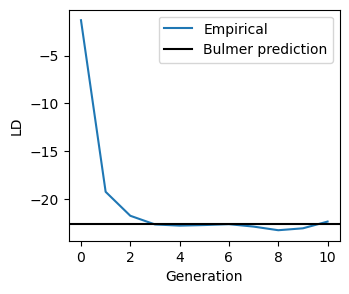

In [338]:
#d = Vg * h^2/(1+h^2+Vp/Vs)

Vs = 0.01
Vg = 2*(num_loci)*p_init*(1-p_init)*beta**2

X = Vs/Vg

d = Vg/(2+Vs/Vg)

d_2 = Vg * (3+X-np.sqrt(1+6*X+X**2))/4

d_3 = Vg**2/Vs
print(d)
print(d_2)
print(d_3)
fig, axs = plt.subplots(1,1,figsize=(3.5, 3))
axs.plot(np.array(sum_ld)*2, label="Empirical")
axs.axhline(-d_2/(2*beta**2), color="k", label="Bulmer prediction")
axs.set_xlabel("Generation")
axs.set_ylabel("LD")
axs.legend()
plt.show()

In [339]:
scores = np.array([19,20,23,25])

In [341]:
from scipy.stats import norm

In [342]:
ndist = norm(np.mean(scores), np.sqrt(np.var(scores)))

In [344]:
1-ndist.cdf(23.5)

0.231535507507294

In [352]:
a = np.array([[0,1,2,3,4], [2,3,4,5,5]])

for i in np.arange(a.shape[0]):
    print(np.unique(a[i, :]).shape[0])
    assert np.unique(a[i, :]).shape[0] == a.shape[1], "test"

5
4


AssertionError: test